# Encoding

#### **Label Encoding**

In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd 

In [2]:
data = {'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']}
df = pd.DataFrame(data)

In [3]:
label_encoder = LabelEncoder()
df['Color_Encoded']= label_encoder.fit_transform(df['Color'])

In [4]:
df

,Color,Color_Encoded
0,Red,2
1,Green,1
2,Blue,0
3,Green,1
4,Red,2


#### **One-Hot Encoding**

In [12]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
data = {'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']}
df = pd.DataFrame(data)

In [14]:
one_hot_encoder = OneHotEncoder()
encoded_colors = one_hot_encoder.fit_transform(df[['Color']])

In [22]:
print(encoded_colors)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 3)>
  Coords	Values
  (0, 2)	1.0
  (1, 1)	1.0
  (2, 0)	1.0
  (3, 1)	1.0
  (4, 2)	1.0


# **Scaling**

#### **Standardization**

In [20]:
from sklearn.preprocessing import StandardScaler

In [26]:
data = {'Age': [25, 45, 35, 50, 23],
        'Income': [50000, 100000, 75000, 120000, 48000]}
df = pd.DataFrame(data)

In [27]:
scaler = StandardScaler()
df[['Age_Standardized', 'Income_Standardized']] = scaler.fit_transform(df[['Age', 'Income']])

print(df)

   Age  Income  Age_Standardized  Income_Standardized
0   25   50000         -0.995228            -1.018936
1   45  100000          0.882561             0.762421
2   35   75000         -0.056334            -0.128258
3   50  120000          1.352008             1.474964
4   23   48000         -1.183007            -1.090191


#### **Min-Max Normalization**

In [29]:
from sklearn.preprocessing import MinMaxScaler


min_max_scaler = MinMaxScaler()
df[['Age_Normalized', 'Income_Normalized']] = min_max_scaler.fit_transform(df[['Age', 'Income']])

print(df)

   Age  Income  Age_Standardized  Income_Standardized  Age_Normalized  \
0   25   50000         -0.995228            -1.018936        0.074074   
1   45  100000          0.882561             0.762421        0.814815   
2   35   75000         -0.056334            -0.128258        0.444444   
3   50  120000          1.352008             1.474964        1.000000   
4   23   48000         -1.183007            -1.090191        0.000000   

   Income_Normalized  
0           0.027778  
1           0.722222  
2           0.375000  
3           1.000000  
4           0.000000  


# **Overfitting**

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # Feature (e.g., size of the house)
y = 2.5 * X**2 + 0.5 * X + np.random.randn(100, 1) * 70  # Increased noise level to induce overfitting

In [34]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Fit a polynomial regression model with a high degree (overfitting scenario)
poly_features = PolynomialFeatures(degree=15)  # High-degree polynomial
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 16)","[[ 0., 0., 0.,..., 0.,-0., 0.]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[28.3]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[1.46e+15,4.08e+12,3.58e+10,...,1.37e-02,1.93e-03,0.00e+00]"


In [36]:
# Predictions
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

In [38]:
# Calculate R² for training and test sets
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [39]:
# Print R²
print(f"Training R² (Overfitting): {train_r2:.2f}")
print(f"Test R² (Overfitting): {test_r2:.2f}")

Training R² (Overfitting): 0.57
Test R² (Overfitting): 0.50


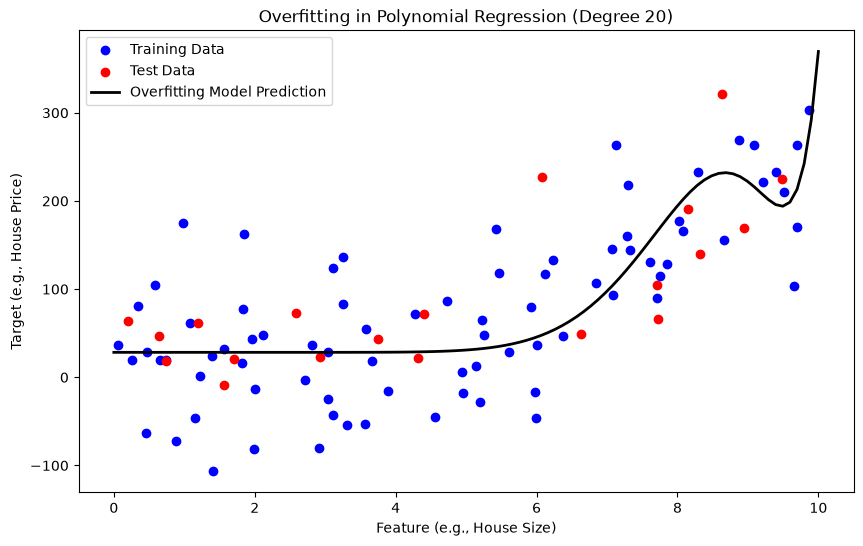

In [40]:
# 6. Plotting the results to show overfitting
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')

X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = model.predict(X_plot_poly)

plt.plot(X_plot, y_plot, color='black', linewidth=2, label='Overfitting Model Prediction')
plt.xlabel("Feature (e.g., House Size)")
plt.ylabel("Target (e.g., House Price)")
plt.title("Overfitting in Polynomial Regression (Degree 20)")
plt.legend()
plt.show()

In [41]:
from sklearn.linear_model import Lasso, Ridge

**Apply L1 (Lasso) Regularization**

In [42]:

# Apply L1 (Lasso) Regularization
lasso_model = Lasso(alpha=0.1)  # The alpha value controls the amount of regularization
lasso_model.fit(X_train_poly, y_train)

# Predictions using Lasso
y_train_pred_lasso = lasso_model.predict(X_train_poly)
y_test_pred_lasso = lasso_model.predict(X_test_poly)

# Calculate R² score for Lasso
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)

print(f"Lasso (L1) Training R²: {train_r2_lasso:.2f}")
print(f"Lasso (L1) Test R²: {test_r2_lasso:.2f}")

Lasso (L1) Training R²: 0.58
Lasso (L1) Test R²: 0.54


/home/zeyad/ai-engineering/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.540748e+05, tolerance: 7.295e+01
  model = cd_fast.enet_coordinate_descent(


**Apply L2 (Ridge) Regularization**

In [43]:
# Apply L2 (Ridge) Regularization
ridge_model = Ridge(alpha=0.1)  # The alpha value controls the amount of regularization
ridge_model.fit(X_train_poly, y_train)

# Predictions using Ridge
y_train_pred_ridge = ridge_model.predict(X_train_poly)
y_test_pred_ridge = ridge_model.predict(X_test_poly)

# Calculate R² score for Ridge
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

print(f"Ridge (L2) Training R²: {train_r2_ridge:.2f}")
print(f"Ridge (L2) Test R²: {test_r2_ridge:.2f}")

Ridge (L2) Training R²: 0.61
Ridge (L2) Test R²: 0.51
